In [2]:
import os

print(os.getcwd())

C:\Users\jyots\OneDrive\Documents\Skills\projects and certificates\house-prices-advanced-regression-techniques


PHASE 1: DATA

In [3]:
import pandas as pd
import numpy as np

df = pd.read_csv("train.csv")
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [4]:
df.shape

(1460, 81)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [6]:
df.isnull().sum().sort_values(ascending=False)

PoolQC         1453
MiscFeature    1406
Alley          1369
Fence          1179
MasVnrType      872
               ... 
ExterQual         0
Exterior2nd       0
Exterior1st       0
RoofMatl          0
SalePrice         0
Length: 81, dtype: int64

In [7]:
df.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [8]:
target = df["SalePrice"]

print(target.mean())
print(target.median())
print(target.min())
print(target.max())
print(target.skew())

180921.19589041095
163000.0
34900
755000
1.8828757597682129


0       -> symmetric
0.5     -> slightly skewed 
1+      -> highly skewed      -> needs log transformation

PHASE 2: EDA

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

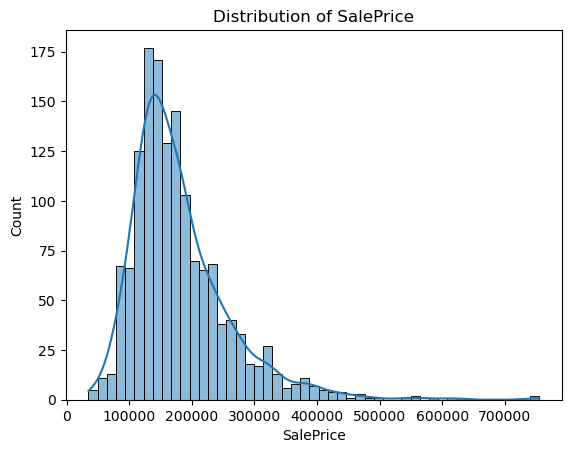

In [10]:
plt.figure()
sns.histplot(df["SalePrice"], kde=True)
plt.title("Distribution of SalePrice")
plt.show()

In [11]:
corr = df.corr(numeric_only=True)
corr["SalePrice"].sort_values(ascending=False).head(20)

SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
GarageYrBlt     0.486362
MasVnrArea      0.477493
Fireplaces      0.466929
BsmtFinSF1      0.386420
LotFrontage     0.351799
WoodDeckSF      0.324413
2ndFlrSF        0.319334
OpenPorchSF     0.315856
HalfBath        0.284108
Name: SalePrice, dtype: float64

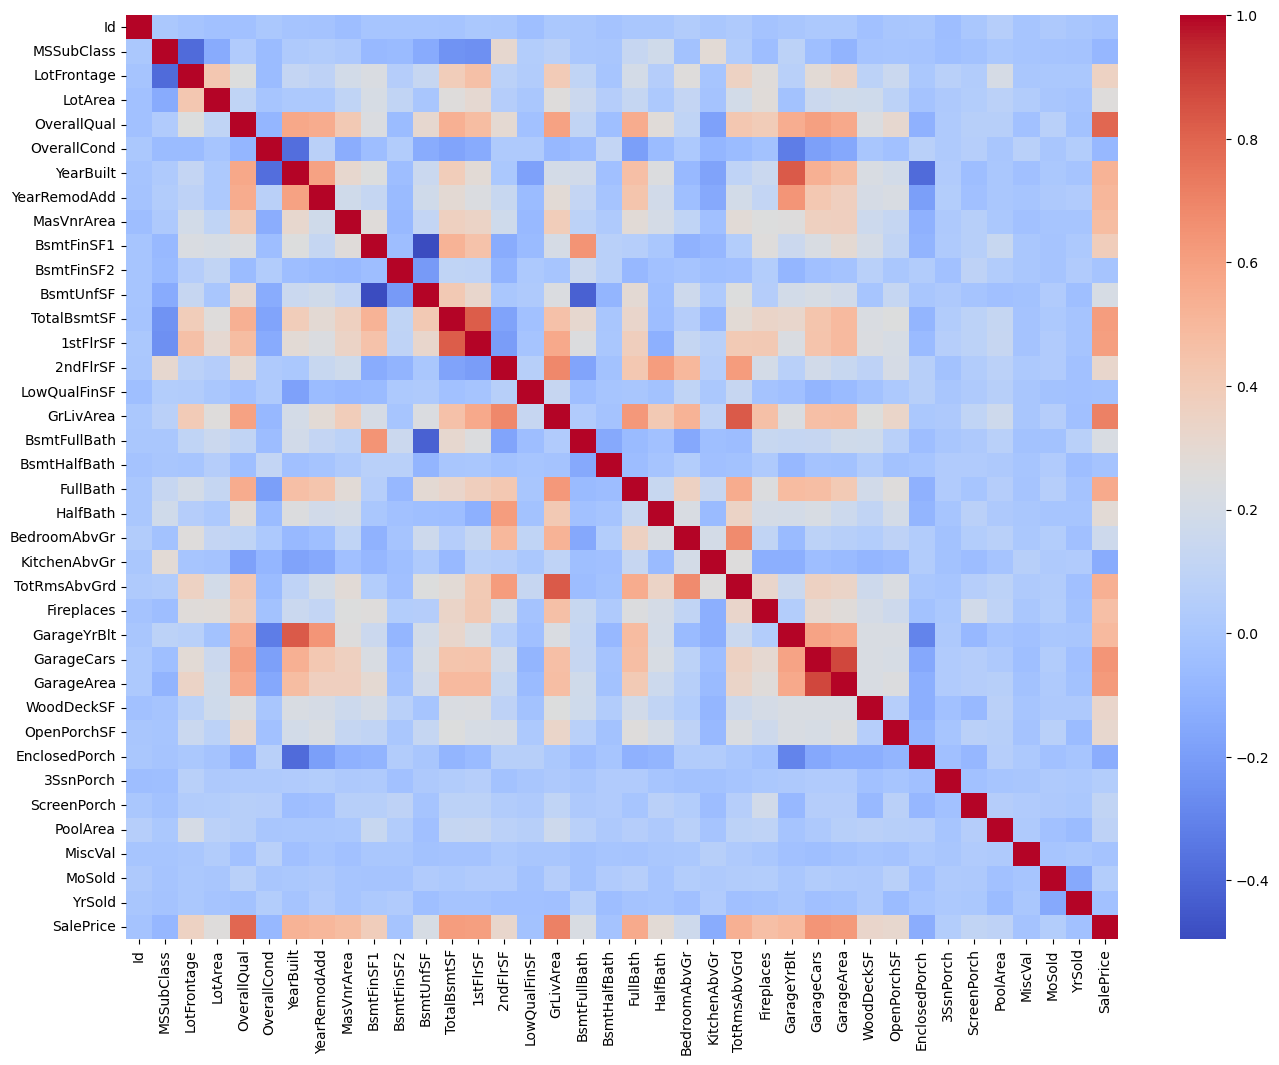

In [12]:
plt.figure(figsize=(16,12))

sns.heatmap(
    corr,
    cmap="coolwarm"
)

plt.show()

In [13]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_percentage.sort_values(ascending=False).head(20)

PoolQC          99.520548
MiscFeature     96.301370
Alley           93.767123
Fence           80.753425
MasVnrType      59.726027
FireplaceQu     47.260274
LotFrontage     17.739726
GarageYrBlt      5.547945
GarageCond       5.547945
GarageType       5.547945
GarageFinish     5.547945
GarageQual       5.547945
BsmtFinType2     2.602740
BsmtExposure     2.602740
BsmtQual         2.534247
BsmtCond         2.534247
BsmtFinType1     2.534247
MasVnrArea       0.547945
Electrical       0.068493
Id               0.000000
dtype: float64

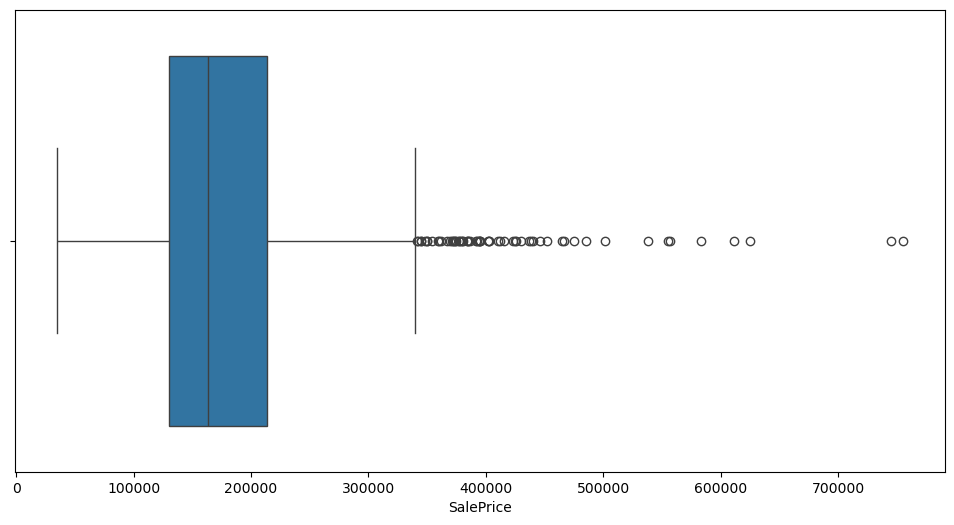

In [14]:
plt.figure(figsize=(12,6))

sns.boxplot(x=df["SalePrice"])

plt.show()

PHASE 3: Feature engineering and data preprocessing

In [15]:
X = df.drop("SalePrice", axis=1)
X = X.drop("Id", axis=1)
y = df["SalePrice"]

print(X.shape)
print(y.shape)

(1460, 79)
(1460,)


In [16]:
y_log = np.log1p(y)

print("Original skewness:", y.skew())
print("Log transformed skewness:", y_log.skew())

Original skewness: 1.8828757597682129
Log transformed skewness: 0.12134661989685333


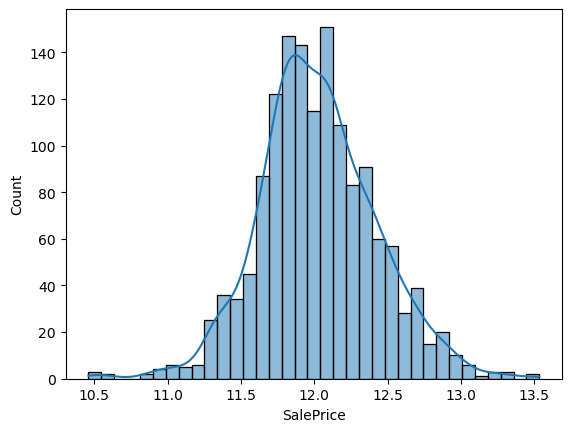

In [17]:
sns.histplot(y_log, kde=True)
plt.show()

In [18]:
num_cols = X.select_dtypes(include=["int64", "float64"]).columns

cat_cols = X.select_dtypes(include=["object"]).columns

print("Numerical:", len(num_cols))
print("Categorical:", len(cat_cols))

Numerical: 36
Categorical: 43


In [19]:
X["TotalSF"] = (
    X["TotalBsmtSF"] +
    X["1stFlrSF"] +
    X["2ndFlrSF"]
)

X["HouseAge"] = (
    X["YrSold"] -
    X["YearBuilt"]
)

X["RemodelAge"] = (
    X["YrSold"] -
    X["YearRemodAdd"]
)

X["TotalBath"] = (
    X["FullBath"] +
    0.5 * X["HalfBath"]
)

X["HasGarage"] = (
    X["GarageArea"] > 0
).astype(int)

X[[
    "TotalSF",
    "HouseAge",
    "RemodelAge",
    "TotalBath",
    "HasGarage"
]].head()

,TotalSF,HouseAge,RemodelAge,TotalBath,HasGarage
0,2566,5,5,2.5,1
1,2524,31,31,2.0,1
2,2706,7,6,2.5,1
3,2473,91,36,1.0,1
4,3343,8,8,2.5,1


In [20]:
X[num_cols].isnull().sum().sort_values(
    ascending=False
).head(20)

LotFrontage      259
GarageYrBlt       81
MasVnrArea         8
WoodDeckSF         0
BedroomAbvGr       0
KitchenAbvGr       0
TotRmsAbvGrd       0
Fireplaces         0
GarageCars         0
GarageArea         0
MSSubClass         0
HalfBath           0
EnclosedPorch      0
3SsnPorch          0
ScreenPorch        0
PoolArea           0
MiscVal            0
MoSold             0
OpenPorchSF        0
FullBath           0
dtype: int64

In [21]:
X[cat_cols].isnull().sum().sort_values(
    ascending=False
).head(20)

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
GarageType        81
GarageCond        81
GarageQual        81
GarageFinish      81
BsmtFinType2      38
BsmtExposure      38
BsmtFinType1      37
BsmtQual          37
BsmtCond          37
Electrical         1
KitchenQual        0
CentralAir         0
Functional         0
HeatingQC          0
dtype: int64

In [22]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import RobustScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [23]:
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", RobustScaler())
])

In [24]:
cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

In [27]:
preprocessor = ColumnTransformer([
    ("num", num_pipeline, num_cols),
    ("cat", cat_pipeline, cat_cols)
])

X_processed = preprocessor.fit_transform(X)

In [28]:
print(X.shape)
print(X_processed.shape)

(1460, 84)
(1460, 287)


PHASE 4: Modeling
LINEAR REGRESSION

In [29]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In [30]:
X_train, X_test, y_train, y_test = train_test_split(
    X_processed,
    y_log,
    test_size=0.2,
    random_state=42
)

In [31]:
lr = LinearRegression()

lr.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [32]:
y_pred = lr.predict(X_test)

In [33]:
r2 = r2_score(y_test, y_pred)

print(X_processed.shape)

print("R² Score:", r2)

(1460, 287)
R² Score: 0.91285746819438


In [34]:
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)
ridge_pred = ridge.predict(X_test)
ridge_r2 = r2_score(y_test, ridge_pred)

print("Ridge R²:", ridge_r2)

Ridge R²: 0.9083359900904207


LASSO REGRESSION

In [35]:
from sklearn.linear_model import Lasso

lasso = Lasso(alpha=0.001)
lasso.fit(X_train, y_train)
lasso_pred = lasso.predict(X_test)
lasso_r2 = r2_score(y_test, lasso_pred)

print("Lasso R²:", lasso_r2)

Lasso R²: 0.8989831912295343


TREES
DECISION TREE

In [36]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(
    random_state=42
)

dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)
dt_r2 = r2_score(y_test, dt_pred)

print("Decision Tree R²:", dt_r2)

Decision Tree R²: 0.8130731738757626


RANDOM FOREST

In [37]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest R²:", rf_r2)

Random Forest R²: 0.8873846936969079


In [38]:
train_pred = rf.predict(X_train)

train_r2 = r2_score(y_train, train_pred)

print('Random Forest')
print("Train R²:", train_r2)
print("Test R²:", rf_r2)

Random Forest
Train R²: 0.9812532084283975
Test R²: 0.8873846936969079


In [39]:
train_pred_lr = lr.predict(X_train)

print('Linear Regression')
print("Train R²:",
      r2_score(y_train, train_pred_lr))

print("Test R²:",
      r2)

Linear Regression
Train R²: 0.9442373908926581
Test R²: 0.91285746819438


GRADIENT BOOSTING REGRESSION

In [40]:
from sklearn.ensemble import GradientBoostingRegressor

gbr = GradientBoostingRegressor(
    random_state=42
)

gbr.fit(X_train, y_train)
gbr_pred = gbr.predict(X_test)
gbr_r2 = r2_score(
    y_test,
    gbr_pred
)

print("Gradient Boosting R²:", gbr_r2)

Gradient Boosting R²: 0.8995275029903158


XG BOOST

In [41]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_test)
xgb_r2 = r2_score(y_test, xgb_pred)

print("XGBoost R²:", xgb_r2)

XGBoost R²: 0.9044747870376193


PHASE 5: Evaluation

In [42]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error

rmse = np.sqrt(
    mean_squared_error(y_test, y_pred)
)

mae = mean_absolute_error(
    y_test,
    y_pred
)

print("RMSE:", rmse)
print("MAE:", mae)

RMSE: 0.12752158251997128
MAE: 0.08894288639958509


CROSS VALIDATION

In [47]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    lr,
    X_processed,
    y_log,
    cv=5,
    scoring="r2"
)

print("CV Scores:")
print(cv_scores)
print("\nMean CV Score:")
print(cv_scores.mean())

CV Scores:
[0.87948218 0.84813364 0.82811071 0.9142411  0.74266781]

Mean CV Score:
0.8425270889567722


HYPERPARAMETER TUNING - XG BOOST

In [48]:
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBRegressor

param_grid = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [3, 4, 5, 6],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.7, 0.8, 1.0],
    "colsample_bytree": [0.7, 0.8, 1.0]
}

xgb = XGBRegressor(
    random_state=42
)

search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_grid,
    n_iter=20,
    scoring="r2",
    cv=5,
    random_state=42,
    n_jobs=-1
)

search.fit(X_train, y_train)

print(search.best_params_)
print(search.best_score_)

{'subsample': 0.8, 'n_estimators': 500, 'max_depth': 4, 'learning_rate': 0.05, 'colsample_bytree': 0.7}
0.8928647686601263


In [49]:
best_xgb = search.best_estimator_

best_pred = best_xgb.predict(X_test)

best_r2 = r2_score(
    y_test,
    best_pred
)

print("Tuned XGBoost R²:", best_r2)

Tuned XGBoost R²: 0.9093871677799502


In [50]:
# Proper Cross Validation Comparison
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score

lr_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

lr_cv = cross_val_score(
    lr_pipeline,
    X,
    y_log,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

print("Linear CV Mean:", lr_cv.mean())

Linear CV Mean: 0.8420864756465036


In [51]:
ridge_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", Ridge(alpha=1.0))
])

ridge_cv = cross_val_score(
    ridge_pipeline,
    X,
    y_log,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

print("Ridge CV Mean:", ridge_cv.mean())

Ridge CV Mean: 0.8633915846331309


In [52]:
xgb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", best_xgb)
])

xgb_cv = cross_val_score(
    xgb_pipeline,
    X,
    y_log,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

print("XGBoost CV Mean:", xgb_cv.mean())

XGBoost CV Mean: 0.9057345272153057


PHASE 6: Explainability

In [53]:
preprocessor.fit(X)

feature_names = preprocessor.get_feature_names_out()

print(len(feature_names))

287


In [56]:
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': best_xgb.feature_importances_
})

importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

print(importance_df.head(20))

                    Feature  Importance
3          num__OverallQual    0.126084
247   cat__GarageFinish_Unf    0.098711
25          num__GarageCars    0.078409
169       cat__ExterQual_TA    0.055018
105      cat__BldgType_1Fam    0.050001
15           num__GrLivArea    0.037409
226     cat__KitchenQual_TA    0.034853
14        num__LowQualFinSF    0.030344
216       cat__CentralAir_N    0.028709
217       cat__CentralAir_Y    0.026253
40         cat__MSZoning_RM    0.024640
181        cat__BsmtQual_Ex    0.021099
244  cat__GarageType_Detchd    0.020685
23          num__Fireplaces    0.015089
21        num__KitchenAbvGr    0.012634
48        cat__LotShape_Reg    0.012326
198   cat__BsmtFinType1_Unf    0.011048
11         num__TotalBsmtSF    0.010924
223     cat__KitchenQual_Ex    0.010146
6         num__YearRemodAdd    0.009189


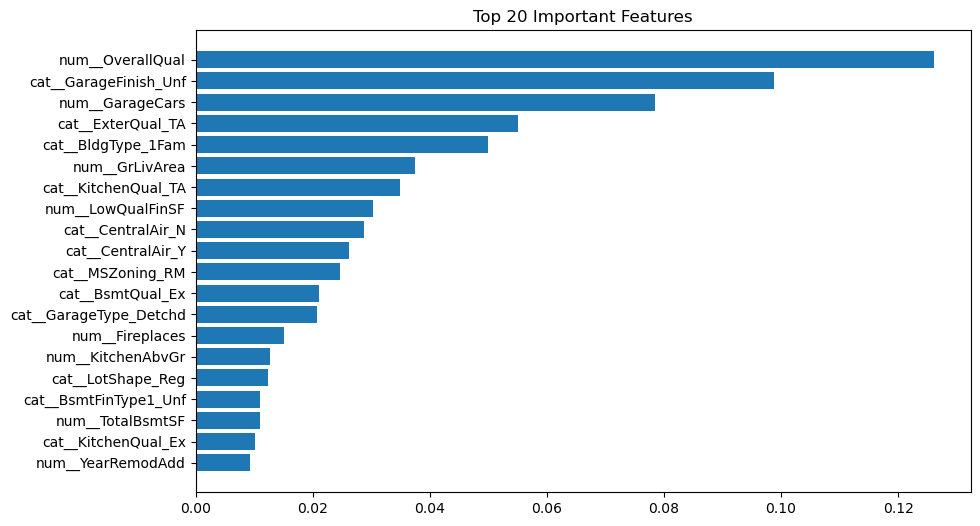

In [57]:
top20 = importance_df.head(20)

plt.figure(figsize=(10,6))

plt.barh(
    top20['Feature'],
    top20['Importance']
)

plt.gca().invert_yaxis()

plt.title("Top 20 Important Features")
plt.show()

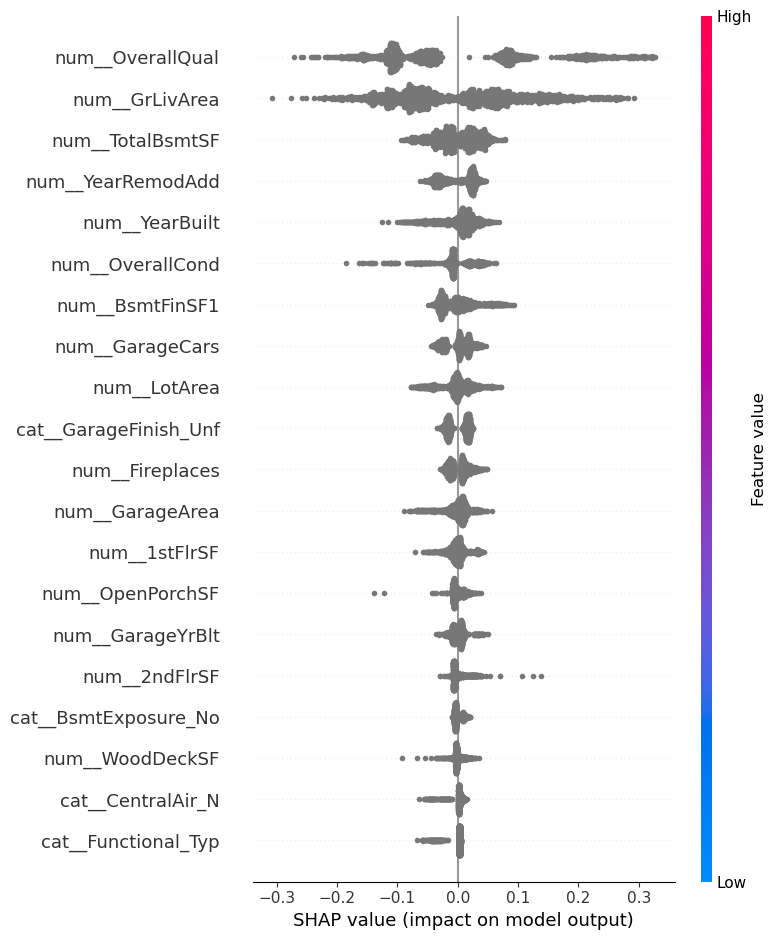

In [62]:
!pip install shap
import shap

X_processed = preprocessor.transform(X)

explainer = shap.TreeExplainer(best_xgb)

shap_values = explainer.shap_values(X_processed)

shap.summary_plot(
    shap_values,
    X_processed,
    feature_names=feature_names
)

In [69]:
print(type(X_processed))

<class 'scipy.sparse._csr.csr_matrix'>


In [66]:
X_dense = X_processed.toarray()

print(type(X_dense))
print(X_dense.shape)

<class 'numpy.ndarray'>
(1460, 287)


In [67]:
X_df = pd.DataFrame(
    X_dense,
    columns=feature_names
)

print(X_df.shape)

X_df.head()

(1460, 287)


,num__MSSubClass,num__LotFrontage,num__LotArea,num__OverallQual,num__OverallCond,num__YearBuilt,num__YearRemodAdd,num__MasVnrArea,num__BsmtFinSF1,num__BsmtFinSF2,...,cat__SaleType_ConLw,cat__SaleType_New,cat__SaleType_Oth,cat__SaleType_WD,cat__SaleCondition_Abnorml,cat__SaleCondition_AdjLand,cat__SaleCondition_Alloca,cat__SaleCondition_Family,cat__SaleCondition_Normal,cat__SaleCondition_Partial
0,0.2,-0.210526,-0.254076,0.5,0.0,0.652174,0.243243,1.193303,0.452790,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
1,-0.6,0.578947,0.030015,0.0,3.0,0.065217,-0.486486,0.000000,0.834679,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
2,0.2,-0.052632,0.437624,0.5,0.0,0.608696,0.216216,0.986301,0.143910,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
3,0.4,-0.473684,0.017663,0.5,0.0,-1.260870,-0.648649,0.000000,-0.235170,0.0,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0
4,0.2,0.789474,1.181201,1.0,0.0,0.586957,0.162162,2.130898,0.381186,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0


In [68]:
explainer = shap.TreeExplainer(best_xgb)

shap_values = explainer.shap_values(X_dense)

print(shap_values.shape)
print(X_df.shape)

(1460, 287)
(1460, 287)


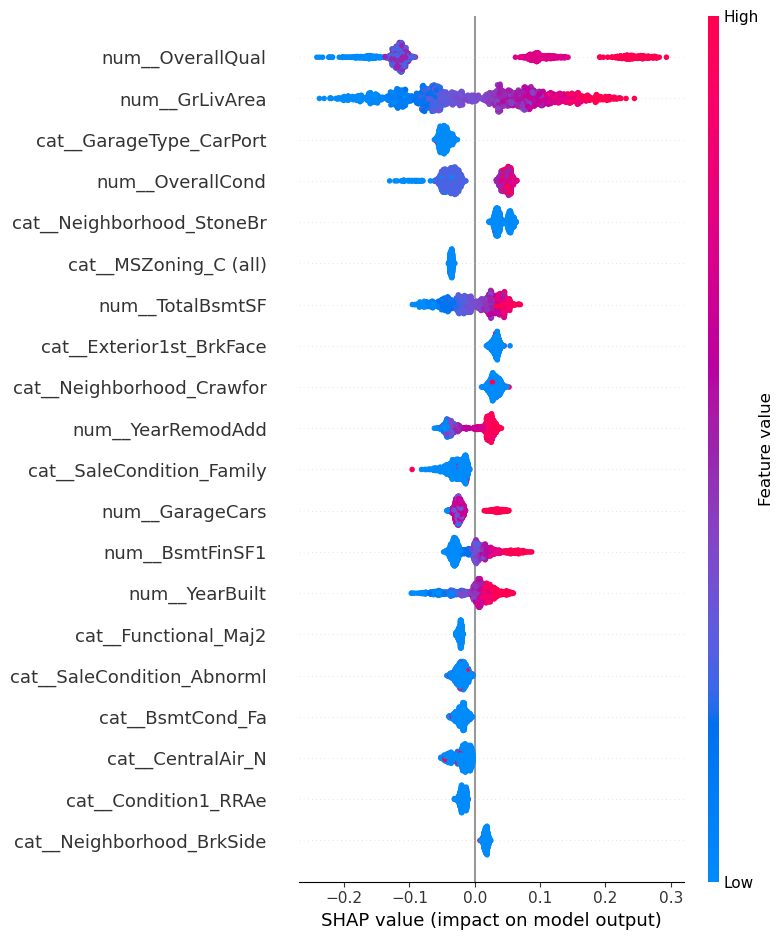

In [70]:
shap.summary_plot(
    shap_values,
    X_df,
    max_display=20
)

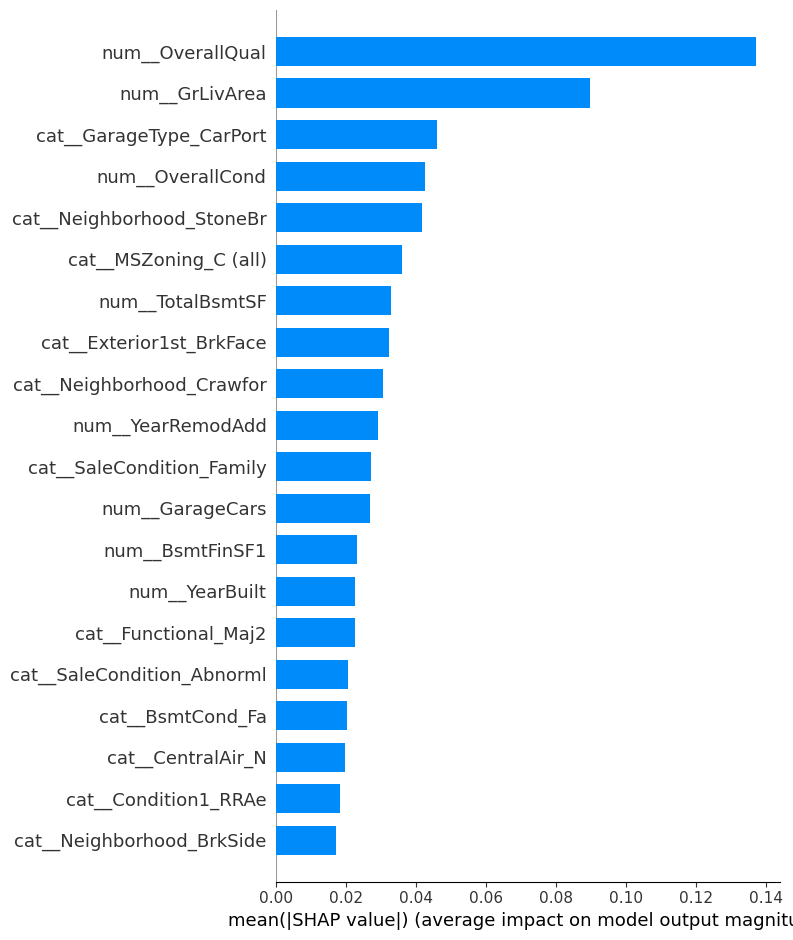

In [71]:
shap.summary_plot(
    shap_values,
    X_df,
    plot_type="bar",
    max_display=20
)

In [72]:
shap_importance = pd.DataFrame({
    'Feature': X_df.columns,
    'Mean_SHAP': np.abs(shap_values).mean(axis=0)
})

shap_importance = shap_importance.sort_values(
    by='Mean_SHAP',
    ascending=False
)

print(shap_importance.head(20))

                        Feature  Mean_SHAP
3              num__OverallQual   0.137125
15               num__GrLivArea   0.089770
243     cat__GarageType_CarPort   0.046034
4              num__OverallCond   0.042552
85    cat__Neighborhood_StoneBr   0.041731
36        cat__MSZoning_C (all)   0.035830
11             num__TotalBsmtSF   0.032663
135    cat__Exterior1st_BrkFace   0.032314
69    cat__Neighborhood_Crawfor   0.030534
6             num__YearRemodAdd   0.029091
284   cat__SaleCondition_Family   0.027079
25              num__GarageCars   0.026626
8               num__BsmtFinSF1   0.023156
5                num__YearBuilt   0.022354
228        cat__Functional_Maj2   0.022348
281  cat__SaleCondition_Abnorml   0.020477
185            cat__BsmtCond_Fa   0.020044
216           cat__CentralAir_N   0.019563
93         cat__Condition1_RRAe   0.018116
66    cat__Neighborhood_BrkSide   0.017090


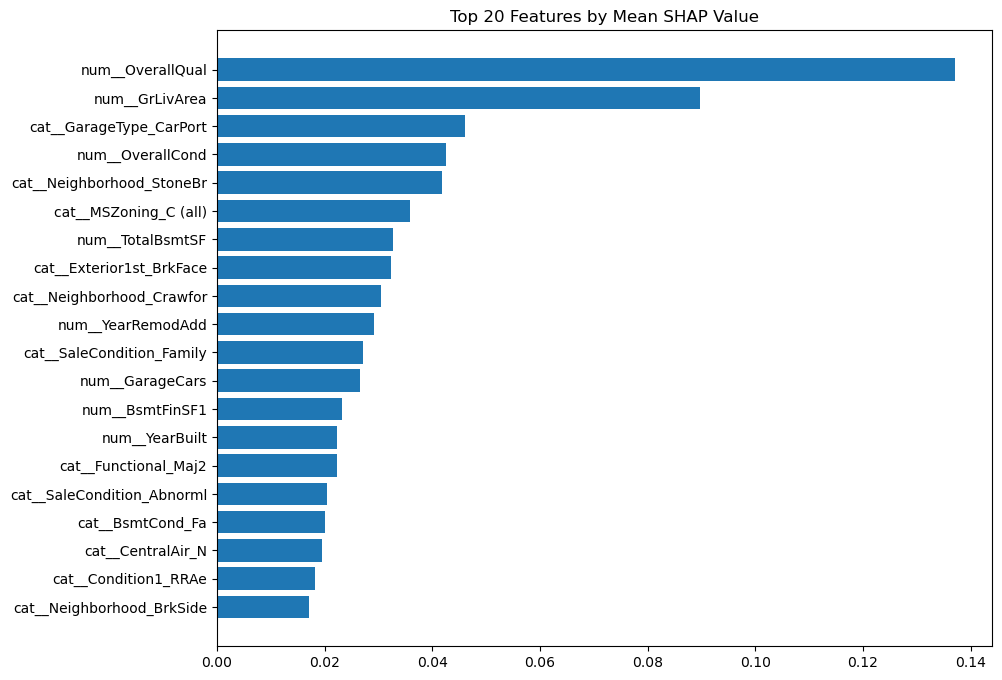

In [74]:
top20 = shap_importance.head(20)

plt.figure(figsize=(10,8))

plt.barh(
    top20['Feature'],
    top20['Mean_SHAP']
)

plt.gca().invert_yaxis()

plt.title("Top 20 Features by Mean SHAP Value")

plt.show()

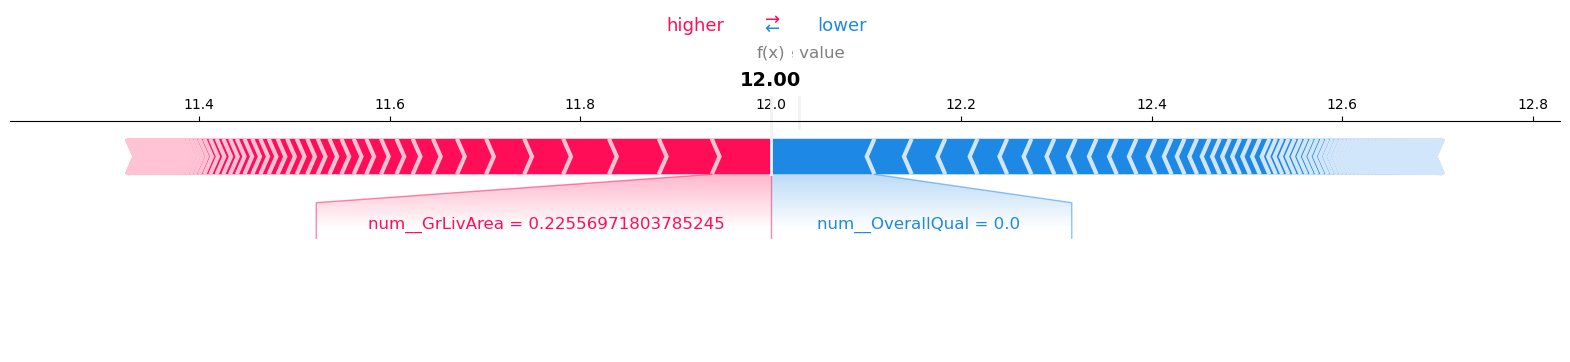

In [75]:
sample_index = 100

shap.force_plot(
    explainer.expected_value,
    shap_values[sample_index],
    X_dense[sample_index],
    feature_names=feature_names,
    matplotlib=True
)